In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from flonacomldft.utils.io_utils import (load_pickle_file,
    get_project_path,
)
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import set_plot_sequential_data 

from flonacomldft.utils.diagnostics import R_hat

In [24]:
#idx = 3190362
#idx = 3187707
#idx = 3187704
idx = 3196155

# Load the data
PROJECT_PATH = get_project_path()
SIMULATIONS_DATA_PATH = PROJECT_PATH+"/1-adaptive"

In [25]:
is_idx = {0: [0, 2],
        1: [1, 3] 
        }   

is_idx[0], is_idx[1]

([0, 2], [1, 3])

In [26]:
adaptive_mlp = {}
cvs_mlp = {}

for i in range(2):
    adaptive_mlp[i] = []

    cvs_mlp[i] = []

    for j in is_idx[i]:
        #try:
        adaptive_mlp[i].append(load_pickle_file("results_adaptive_is{:d}_{:d}{:d}/adaptive_sampling_is{:d}_{:d}{:d}.pkl".format(
            i, idx, j, i, idx, j), path=SIMULATIONS_DATA_PATH))
        cvs_mlp[i].append(load_pickle_file("results_adaptive_is{:d}_{:d}{:d}/cvs_is{:d}_{:d}{:d}.pkl".format(
            i, idx, j, i, idx, j), path=SIMULATIONS_DATA_PATH))
        success = True
        print(adaptive_mlp[i][-1]['args']['isomer_label'], i, success)
        #except:
        #    pass
            #adaptive_mlp[i].append(None)


        #try:
        #    cvs_mlp[i].append(load_pickle_file("results_adaptive_is{:d}_{:d}{:d}/cvs_is{:d}_{:d}{:d}.pkl".format(
        #        i, idx, j, i, idx, j), path=SIMULATIONS_DATA_PATH))
        #except:
        #    pass
        #    #cvs_mlp[i].append(None)

        #cvs_mlp[i].append(load_pickle_file("results_adaptive_is{:d}_{:d}{:d}/cvs_is{:d}_{:d}{:d}.pkl".format(
        #    i, idx, j, i, idx, j), path=SIMULATIONS_DATA_PATH))
    
    #adaptive = load_pickle_file("results_adaptive_is{:d}_{:d}{:d}/adaptive_sampling_is{:d}_{:d}{:d}.pkl".format(
    #    i, idx, j, i, idx, j), path=SIMULATIONS_DATA_PATH) for j in is_idx[i]]
#
    #cvs = load_pickle_file("results_adaptive_is{:d}_{:d}{:d}/cvs_is{:d}_{:d}{:d}.pkl".format(
    #    i, idx, j, i, idx, j), path=SIMULATIONS_DATA_PATH) for j in is_idx[i]]

[0] 0 True
[0] 0 True
[1] 1 True
[1] 1 True


In [27]:
adaptive_mlp[0][0]['args'].keys()

dict_keys(['threads', 'process_id', 'random_seed', 'folder_path', 'dataset', 'N_md_points', 'N_random_points', 'isomer_label', 'flow_n_iter', 'flow_learning_rate', 'flow_batch_size', 'n_blocks', 'hidden_dim', 'hidden_depth', 'flow_use_scheduler', 'flow_step_scheduler', 'mlp_n_iter', 'mlp_learning_rate', 'mlp_batch_size', 'mlp_use_scheduler', 'mlp_step_scheduler', 'temperature', 'n_runs', 'n_chains', 'n_steps', 'energy_type', 'frac_computed', 'train_mlps', 'load_models', 'flow_type', 'update_weights', 'scheduler_weights', 'alpha', 'mlps_id', 'flows_id', 'cycles', 'date_start', 'date_end', 'algorithm', 'time_init'])

In [28]:
def mlp_samples(idx):
    idx=str(idx)
    if idx[-1]=='0' or idx[-1]=='3' or idx[-1]=='6' or idx[-1]=='9':
        rd_samples_mlp = 500 + 500
    elif idx[-1]=='1' or idx[-1]=='4' or idx[-1]=='7' or idx[-1]=='10':
        rd_samples_mlp = 1000 + 500
    elif idx[-1]=='2' or idx[-1]=='5' or idx[-1]=='8' or idx[-1]=='11':
        rd_samples_mlp = 1500 + 500
    else:
        rd_samples_mlp = 'Error'
    return str(rd_samples_mlp)


In [29]:
#mlp_samples(adaptive_mlp[0][0]['args']['mlps_id'][0])

In [30]:
#adaptive_mlp[0][0]['args']

In [31]:
len(adaptive_mlp[0])

2

In [32]:
accs = {}

for i in range(2):
    accs[i] = {' bs: ' + str(adaptive_mlp[i][j]['args']['flow_batch_size']) + ' n_iter: ' + str(adaptive_mlp[i][j]['args']['flow_n_iter']): torch.cat(adaptive_mlp[i][j]['accs']).float().mean(dim=1) 
                    for j in range(len(adaptive_mlp[i]))}    

# Plotting acceptances

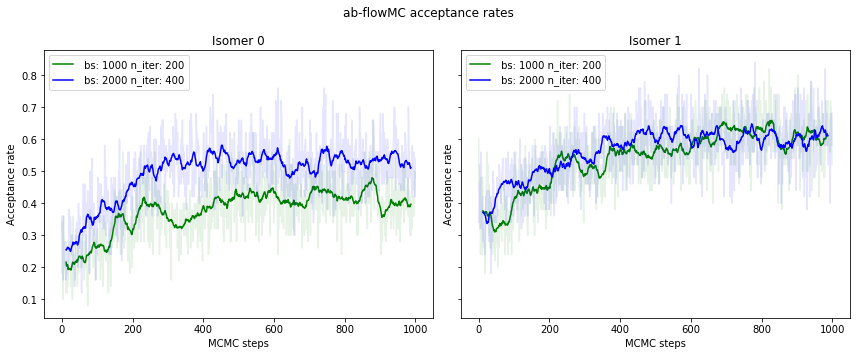

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = ['g', 'b', 'r', 'c', 'm', 'y']

for i in range(2):
    for m, k in enumerate(accs[i].keys()):
        set_plot_sequential_data(accs[i][k], ax=ax[i], color=colors[m], window_size=25, alpha=0.1, label="{:s}".format(k))
    ax[i].set_xlabel("MCMC steps")
    ax[i].set_ylabel("Acceptance rate")
    ax[i].legend()

    ax[i].set_title("Isomer {:d}".format(i))

fig.suptitle("ab-flowMC acceptance rates")
plt.tight_layout()

# Plot $\hat{R}$

In [34]:
#cvs_mlp[0][0].shape, torch.cat(adaptive_mlp[0][0]['us']).reshape(-1, 50, 1).shape

In [35]:
us_cvs = {}

for i in range(2):
    print("sims: , cvs", (len(adaptive_mlp[i]), len(cvs_mlp[i])))
    us_cvs[i] = {' bs: ' + str(adaptive_mlp[i][j]['args']['flow_batch_size']) + ' n_iter: ' + str(adaptive_mlp[i][j]['args']['flow_n_iter']): torch.cat((cvs_mlp[i][j], torch.cat(adaptive_mlp[i][j]['us']).reshape(-1, 50, 1)), dim=2)
                    for j in range(len(cvs_mlp[i]))}
    print(j)

sims: , cvs (2, 2)
3
sims: , cvs (2, 2)
3


In [36]:
rhat = {}

for i in range(2):
    rhat[i] = {k: R_hat(us_cvs[i][k].detach().numpy().transpose(1, 0, 2), labels=['C', 'R', 'U']) for k in us_cvs[i].keys()}

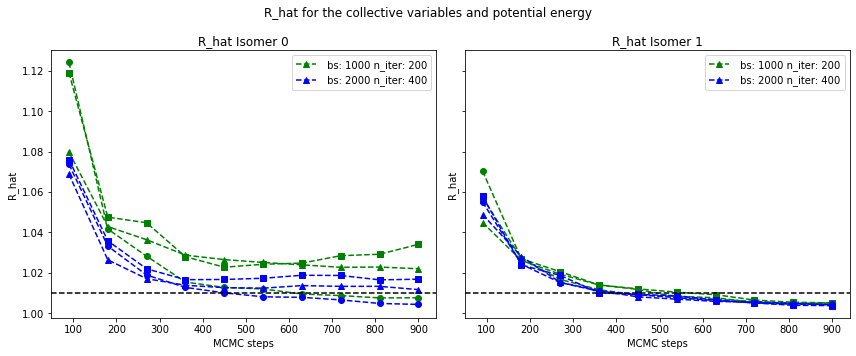

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
markers = ['o', 's', '^']
for i in range(2):
    for m, k in enumerate(rhat[i].keys()):
        for j in range(3):
            ax[i].plot( rhat[i][k][1], rhat[i][k][0][:, j], '--', marker=markers[j], color=colors[m], label="{:s}".format(k))
    ax[i].axhline(1.01, color='k', linestyle='--')
    ax[i].set_xlabel("MCMC steps")
    ax[i].set_ylabel("R_hat")

    handles, labels = ax[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax[i].legend(by_label.values(), by_label.keys())

    ax[i].set_title("R_hat Isomer {:d}".format(i))

fig.suptitle("R_hat for the collective variables and potential energy")
plt.tight_layout()


# Energy histograms

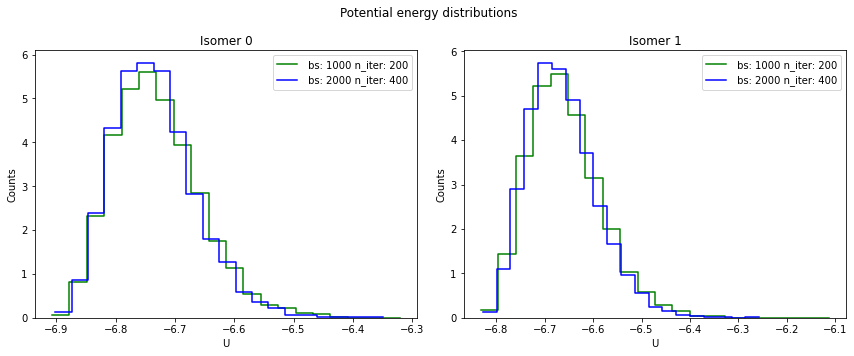

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    j = 0
    for k in us_cvs[i].keys():
        
        #ax[i].hist(us_cvs[i][k][:, :, 2].flatten(), 
        #bins=20, 
        #alpha=0.8,
        #density=True,
        #color=colors[j],
        #label="{:s}".format(k))

        sns.histplot(us_cvs[i][k][:, :, 2].flatten(),
        bins=20,
        fill=False,
        color=colors[j],
        stat="density",
        element="step",
        ax=ax[i],
        label="{:s}".format(k))

        j += 1
    ax[i].set_xlabel("U")
    ax[i].set_ylabel("Counts")
    ax[i].legend()
    ax[i].set_title("Isomer {:d}".format(i))

fig.suptitle("Potential energy distributions")
plt.tight_layout()

In [39]:
flatten_list = lambda list: [item for sublist in list for item in sublist]

# NLL vs Energies

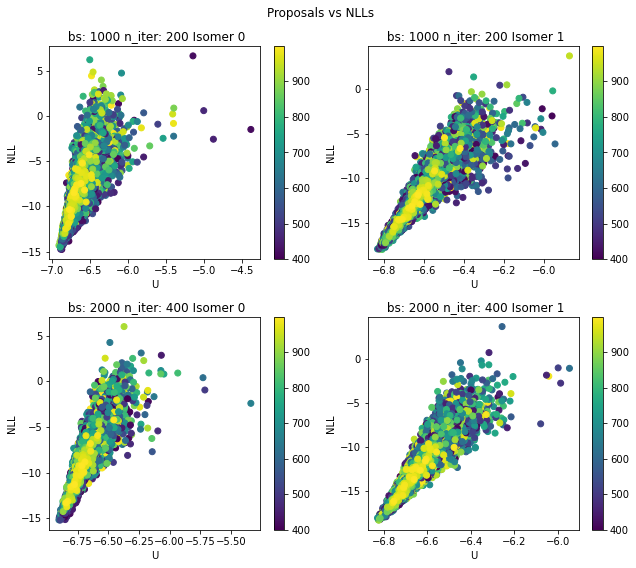

In [40]:
nsubs = len(us_cvs[1].keys())

fig, axs = plt.subplots(nsubs, 2, figsize=(nsubs*4.5, 8))


for i in range(2):
    k=0
    for j, ax, k in zip(us_cvs[i].keys(), axs[:, i], range(len(us_cvs[i].keys()))):

        us_props = torch.cat(adaptive_mlp[i][k]['us_proposals'])
        nlls_props = torch.cat(adaptive_mlp[i][k]['nlls_proposals'])

        k+=1

        for m in range(us_props.shape[1]):
            im = ax.scatter(us_props[400:, m], nlls_props[400:, m], cmap='viridis', c=range(400, us_props.shape[0]))
            ax.set_xlabel("U")
            ax.set_ylabel("NLL")
            ax.set_title(j + ' Isomer {:d}'.format(i))
        
        plt.colorbar(im, ax=ax)

fig.suptitle("Proposals vs NLLs")
plt.tight_layout()

# Flow losses

2
0  bs: 1000 n_iter: 200 0
0  bs: 2000 n_iter: 400 1
2
1  bs: 1000 n_iter: 200 0
1  bs: 2000 n_iter: 400 1


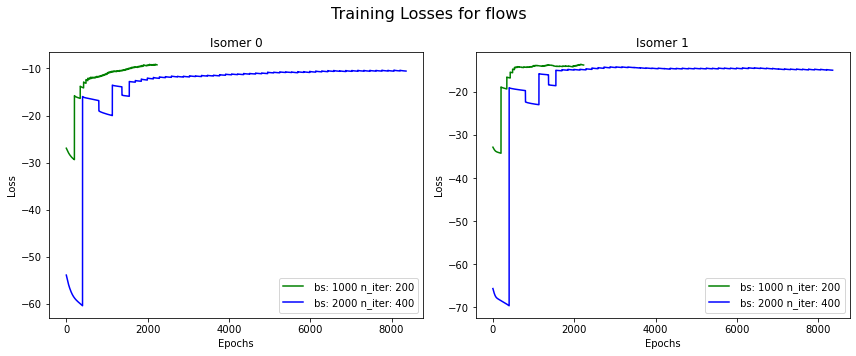

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i in range(2):
    
    print(len(us_cvs[i].keys()))
    for j, k in zip(us_cvs[i].keys(), range(len(us_cvs[i].keys()))):
        print(i, j, k)
        #train_losses = adaptive_mlp[i][k]['dict_flows'][-1][0]['avg_train_losses']
        train_losses = flatten_list([adaptive[0]['avg_train_losses'] for adaptive in adaptive_mlp[i][k]['dict_flows']])

        axs[i].plot(train_losses, color=colors[k], label=j)
        #ax.plot(est_losses, label='test')
        #ax.set_yscale('log')

        axs[i].set_xlabel("Epochs")
        axs[i].set_ylabel("Loss")
        axs[i].set_title("Isomer {:d}".format(i))
        axs[i].legend()

        
#title for figure
fig.suptitle('Training Losses for flows', fontsize=16)
plt.tight_layout()
